In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
from pathlib import Path
from io import BytesIO

import gc
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from zipfile import ZipFile
import numpy as np
import pandas as pd
import requests
import torch
import torch.nn.functional as F
from PIL import Image

from torchvision.models.detection import (
    MaskRCNN_ResNet50_FPN_V2_Weights, maskrcnn_resnet50_fpn_v2
)
from transformers import (
    AutoImageProcessor,
    AutoModelForSemanticSegmentation
)

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

Device: cuda


In [5]:
DATASET_URL = (
    "https://github.com/ultralytics/"
    "assets/releases/download/v0.0.0/"
    "crack-seg.zip"
)

DATASETS_ROOT = Path("/content/datasets")
ARCHIVE_PATH = DATASETS_ROOT / "crack-seg.zip"
DATASET_ROOT = DATASETS_ROOT / "crack-seg"

DATASETS_ROOT.mkdir(parents=True, exist_ok=True)

SPLITS = ("train", "val", "test")
EXPECTED_COUNTS = {"train": 3717, "val": 200, "test": 112}
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

dataset_ready = (DATASET_ROOT / "images" / "train").is_dir()

if not dataset_ready:
    if not ARCHIVE_PATH.is_file():
        torch.hub.download_url_to_file(
            DATASET_URL, str(ARCHIVE_PATH), progress=True
        )

    with ZipFile(ARCHIVE_PATH, "r") as zip_file:
        zip_file.extractall(DATASETS_ROOT)


if not DATASET_ROOT.is_dir():
    candidates = [
        path for path in DATASETS_ROOT.rglob("*")
        if path.is_dir() and (path / "images").is_dir() and "crack" in path.name.lower()
    ]

    if len(candidates) != 1:
        candidates = [
            path for path in DATASETS_ROOT.rglob("images")
            if path.is_dir()
        ]
        if len(candidates) == 1:
            candidates = [candidates[0].parent]


    DATASET_ROOT = candidates[0]

for split in SPLITS:
    required_directories = [
        (DATASET_ROOT / "images" / split),
        (DATASET_ROOT / "labels" / split)
    ]
    
    for directory in (required_directories):
        if not directory.is_dir():
            raise FileExistsError(directory)

print("Dataset extracted:", DATASET_ROOT)

100%|██████████| 91.6M/91.6M [00:01<00:00, 93.4MB/s]


Dataset extracted: /content/datasets


**Paths and clinic image**

In [ ]:
DATASET_ROOT = Path("/content/datasets")
VAL_IMAGES_DIR = DATASET_ROOT / "images" / "val"

BLOCK_05_ROOT = Path(
    "/content/drive/MyDrive/"
    "vision_unit_02_outputs/"
    "block_05"
)

CLINIC_ROOT = BLOCK_05_ROOT / "model_clinic"
CLINIC_ROOT.mkdir(parents=True,exist_ok=True)

selected_manifest_path = (
    BLOCK_05_ROOT
    / "sam3_demo"
    / "sam3_selected_images.csv"
)

if selected_manifest_path.is_file():
    selected_manifest = pd.read_csv(selected_manifest_path)
    crack_image_path = (
        VAL_IMAGES_DIR / selected_manifest.iloc[0]["image"]
    )

else:
    image_suffixes = {".jpg", ".jpeg", ".png"}

    crack_image_path = next(
        path for path in sorted(VAL_IMAGES_DIR.iterdir())
        if path.suffix.lower() in image_suffixes
    )


crack_image = Image.open(crack_image_path).convert("RGB")

print("Clinic image:", crack_image_path.name)
print("Image size:", crack_image.size)

Clinic image: 2122.rf.4ed10b8ba9d48f3c0abfac28e1ff22c7.jpg
Image size: (416, 416)


## Mask R-CNN

In [7]:
standard_image_url = (
    "https://raw.githubusercontent.com/"
    "pytorch/vision/main/gallery/"
    "assets/dog1.jpg"
)

response = requests.get(standard_image_url, timeout=30,)
response.raise_for_status()

standard_image = Image.open(BytesIO(response.content)
).convert("RGB")

In [8]:
mask_rcnn_weights = MaskRCNN_ResNet50_FPN_V2_Weights.DEFAULT

mask_rcnn_model = maskrcnn_resnet50_fpn_v2(weights=mask_rcnn_weights).to(DEVICE).eval()

mask_rcnn_preprocess = mask_rcnn_weights.transforms()
coco_categories = mask_rcnn_weights.meta["categories"]

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth


100%|██████████| 177M/177M [00:01<00:00, 126MB/s]  


In [9]:
def run_mask_rcnn(image):
    input_tensor = mask_rcnn_preprocess(image).to(DEVICE)
    
    with torch.inference_mode():
        output = mask_rcnn_model([input_tensor])[0]
    
    return {
        key: value.detach().cpu() 
        for key, value in output.items()
    }

In [10]:
standard_output = run_mask_rcnn(standard_image)
crack_output = run_mask_rcnn(crack_image)

mask_rcnn_raw_shapes = {
    key: list(value.shape)
    for key, value in standard_output.items()
}

print("Standard output shapes:")

for key, shape in (mask_rcnn_raw_shapes.items()):
    print(f"{key:>8}: {shape}")

Standard output shapes:
   boxes: [3, 4]
  labels: [3]
  scores: [3]
   masks: [3, 1, 500, 500]


**Mask R-CNN visualization**

In [11]:
def visualize_mask_rcnn(
    axis, image,
    output, title,
    score_threshold=0.70,
):

    image_array = np.asarray(image).astype(np.float32) / 255.0
    
    keep = (output["scores"] >= score_threshold)

    boxes = output["boxes"][keep].numpy()
    
    labels =  output["labels"][keep].numpy()
    
    scores = output["scores"][keep].numpy()
    
    masks = (output["masks"][keep, 0] >= 0.50).numpy()

    canvas = image_array.copy()

    colors = plt.cm.tab10(
        np.linspace(
            0, 1, max(len(masks), 1)
        )
    )[:, :3]

    for index, mask in enumerate(masks):
        canvas[mask] = (
            0.55 * canvas[mask]
            + 0.45 * colors[index]
        )

    axis.imshow(canvas)

    for index, (box, label_id, score) in enumerate(
        zip(boxes, labels, scores)
    ):

        x1, y1, x2, y2 = box
        rectangle = patches.Rectangle(
            (x1, y1), x2 - x1,
            y2 - y1, linewidth=2,
            edgecolor=colors[index], facecolor="none"
        )

        axis.add_patch(rectangle)
        class_name = coco_categories[int(label_id)]
        

        axis.text(
            x1,
            max(0, y1 - 5),
            (
                f"{class_name} "
                f"{score:.2f}"
            ),
            color="white", fontsize=9,
            backgroundcolor="black",
        )

    if len(masks) == 0:
        axis.text(
            0.5, 0.05,
            (
                "No COCO instance "
                "above threshold"
            ),
            transform=axis.transAxes,
            horizontalalignment=(
                "center"
            ),
            color="red",
            backgroundcolor="white",
        )

    axis.set_title(
        f"{title}\n"
        f"Kept instances: "
        f"{len(masks)}"
    )

    axis.axis("off")
    return len(masks)

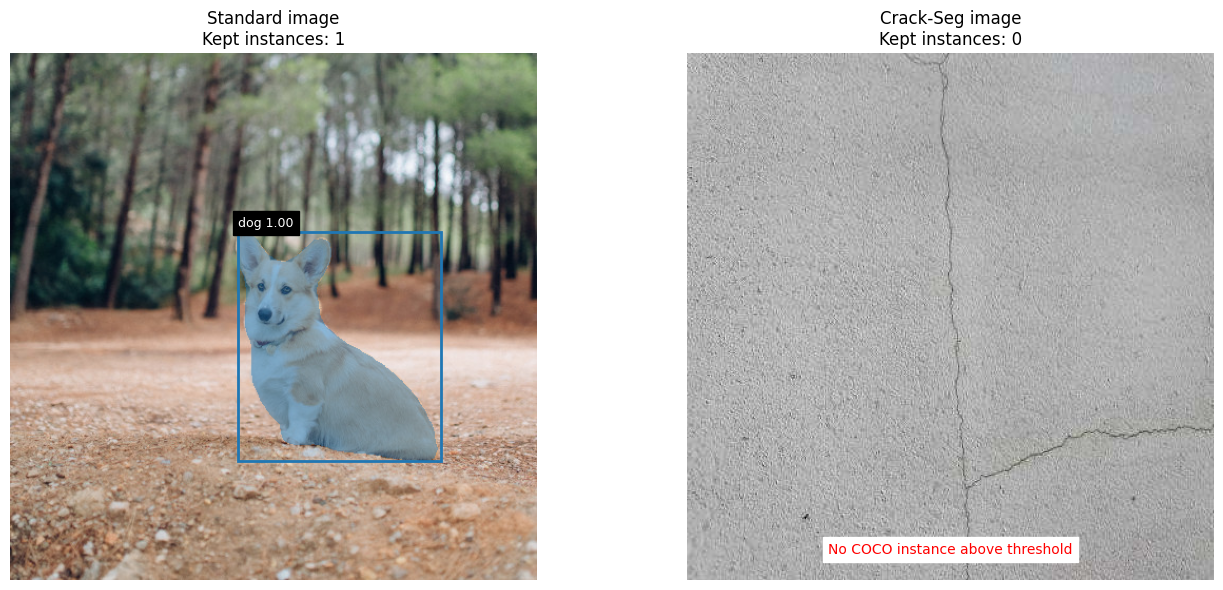

In [12]:
figure, axes = plt.subplots( 1, 2, figsize=(14, 6))

standard_kept = (
    visualize_mask_rcnn(
        axes[0],
        standard_image, standard_output,
        "Standard image", score_threshold=0.70
    )
)

crack_kept = (
    visualize_mask_rcnn(
        axes[1],
        crack_image, crack_output,
        "Crack-Seg image", score_threshold=0.70
    )
)

figure.tight_layout()
mask_rcnn_figure_path = CLINIC_ROOT / "mask_rcnn_clinic.png"

figure.savefig(
    mask_rcnn_figure_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

In [13]:
del mask_rcnn_model
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

## SegFormer

In [14]:
SEGFORMER_CHECKPOINT = (
    "nvidia/"
    "segformer-b0-finetuned-"
    "ade-512-512"
)

segformer_processor = AutoImageProcessor.from_pretrained(SEGFORMER_CHECKPOINT)

segformer_model = AutoModelForSemanticSegmentation.from_pretrained(SEGFORMER_CHECKPOINT).to(DEVICE).eval()

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/6.88k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 15.0MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

In [15]:
segformer_inputs = segformer_processor(
    images=crack_image, return_tensors="pt"
)

segformer_inputs = {
    key: value.to(DEVICE)
    for key, value in segformer_inputs.items()
}

with torch.inference_mode():
    segformer_outputs = segformer_model(**segformer_inputs)


raw_logits = segformer_outputs.logits

target_height = crack_image.height
target_width = crack_image.width

resizes_logits = F.interpolate(
    raw_logits, 
    size=(target_height, target_width),
    mode="bilinear", align_corners=False
)

semantic_mask = resizes_logits.argmax(dim=1)[0].cpu().numpy()

print("Raw logits:", raw_logits.shape)
print("Final mask:",semantic_mask.shape)

Raw logits: torch.Size([1, 150, 128, 128])
Final mask: (416, 416)


**Dominant semantic classes**

In [16]:
class_ids, pixel_counts = np.unique(semantic_mask, return_counts=True)

pixel_ratios = pixel_counts / semantic_mask.size
order = np.argsort(pixel_ratios)[::-1]

top_class_rows = []

for index in order[:8]:
    class_id = int(class_ids[index])
    
    class_name = segformer_model.config.id2label.get(class_id, str(class_id))
    
    top_class_rows.append(
        {
            "class_id": class_id,
            "class_name": class_name,
            "pixel_ratio": float(pixel_ratios[index])
        }
    )

top_classes = pd.DataFrame(top_class_rows)
top_classes

,class_id,class_name,pixel_ratio
0,2,sky,0.783613
1,3,floor,0.147894
2,13,earth,0.047817
3,16,mountain,0.019994
4,28,rug,0.000335
5,4,tree,0.000191
6,9,grass,0.000133
7,34,rock,0.000023


**SegFormer visualization**

In [17]:
number_of_classes = raw_logits.shape[1]
palette_rng = np.random.default_rng(42)

palette = palette_rng.integers(
    0, 256,
    size=(number_of_classes, 3), dtype=np.uint8
)

colored_semantic_mask = palette[semantic_mask]
crack_image_array = np.asarray(crack_image)

semantic_overlay = (
    0.55
    * crack_image_array
    + 0.45
    * colored_semantic_mask
).astype(np.uint8)

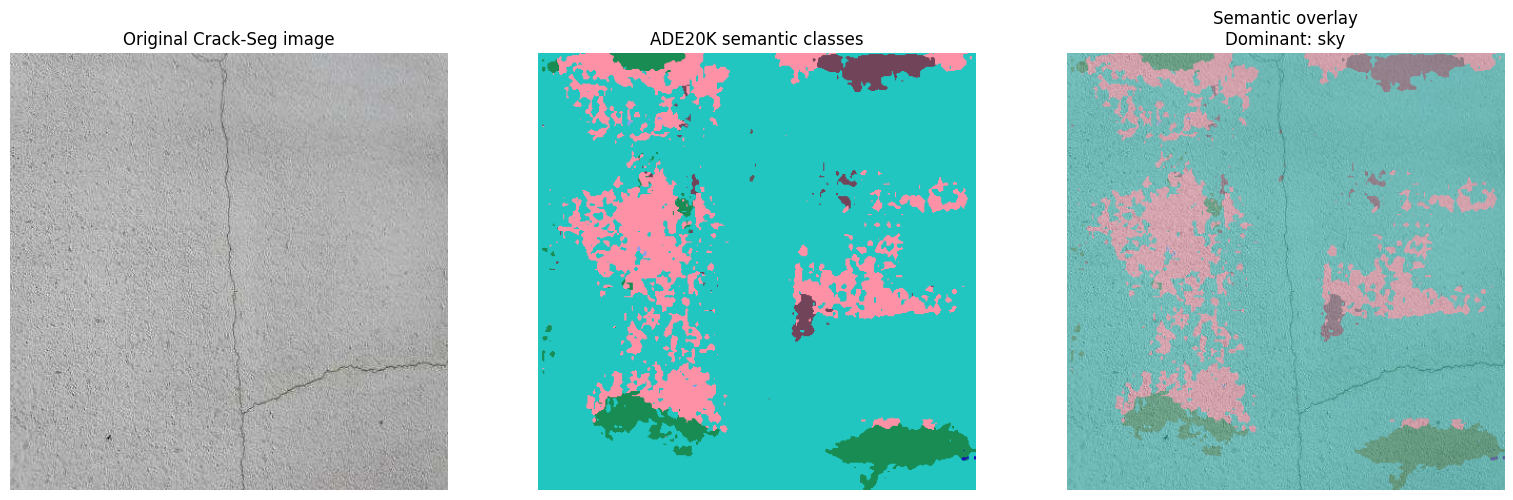

In [18]:
figure, axes = plt.subplots(1, 3, figsize=(16, 5),)

axes[0].imshow(crack_image_array)
axes[0].set_title("Original Crack-Seg image")

axes[1].imshow(colored_semantic_mask)
axes[1].set_title("ADE20K semantic classes")

axes[2].imshow(semantic_overlay)

dominant_label = top_classes.iloc[0]["class_name"]

axes[2].set_title(
    "Semantic overlay\n"
    f"Dominant: "
    f"{dominant_label}"
)

for axis in axes:
    axis.axis("off")

figure.tight_layout()
segformer_figure_path = (
    CLINIC_ROOT
    / "segformer_clinic.png"
)

figure.savefig(
    segformer_figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()